In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modified_rf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from modified_rf import RandomForestRegressor621
from importlib import reload

reload(modified_rf)

np.random.seed(24)

Featurespace = pd.read_csv('TMB Featurespace.csv')
TMB = pd.read_csv('TMB Outputs.csv')

def read_label_data(name, ID):
    data = pd.read_csv(name)
    data
    X = data.iloc[0:,2:].to_numpy()
    
    #Normalizes features for each study
    mean = np.mean(X, axis = 0)
    std = np.std(X, axis = 0)
    X = (X - mean)/std

    #Adds label featured
    X = np.column_stack((X,[ID]*len(X)))

    y = data.iloc[0:,1].to_numpy()
    y = np.log(y+0.1) - np.median(np.log(y+0.1))

    return X, y

X, y = read_label_data('Data/TMB_F1CDX_data.xlsx - thca_tcga_pub.csv', 0)

Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - blca_tcga_pub.csv', 1)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ov_tcga_pub.csv', 2)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kich_tcga_pub.csv', 3)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - coadread_tcga_pub.csv', 4)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kirc_tcga_pub.csv', 5)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - sarc_tcga_pub.csv', 6)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - brca_tcga_pub.csv', 7)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - stad_tcga_pub.csv', 8)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - hnsc_tcga_pub.csv', 9)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ucec_tcga_pub.csv', 10)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - luad_tcga_pub.csv', 11)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - lusc_tcga_pub.csv', 12)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - laml_tcga_pub.csv', 13)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - gbm_tcga_pub.csv', 14)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - prad_tcga_pub.csv', 15)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

def forest(label_depth, n_estimators):
    rf1 = RandomForestRegressor621(n_estimators=n_estimators, min_samples_leaf=5, max_features=0.35, max_depth=None, label_depth=label_depth, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\nLinear Test Accuracy:",accuracy_score)
    
    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)

    #calculate accuracy for each dataset in Xtest
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    sourced_X_test = []
    sourced_train_score = []
    for val in unique_vals:
        sourced_test = X_test[X_test[:, -1] == val]
        sourced_key = y_test[X_test[:, -1] == val]
        sourced_X_test.append(sourced_test)
        sourced_train_score.append(rf1.score(sourced_test, sourced_key))


    return train_score, accuracy_score, rf1, sourced_train_score

In [2]:
'''Forest Training block'''
train_score = []
accuracy_score = []
rf1 = []
sourced_accuracy_scores=[]

for i in range(8):
    print("forest", i)
    temp_train_score, temp_accuracy_score, temp_rf1, sourced_accuracy_score = forest(i, 500)
    train_score.append(temp_train_score)
    accuracy_score.append(temp_accuracy_score)
    rf1.append(temp_rf1)
    sourced_accuracy_scores.append(sourced_accuracy_score)

sourced_accuracy_scores = np.array(sourced_accuracy_scores)

forest 0
Tree: 499
Linear Test Accuracy: 0.34833177427741846

 Training Accuracy: 0.7880727331438974
forest 1
Tree: 499
Linear Test Accuracy: 0.3432418924049756

 Training Accuracy: 0.7880367229438937
forest 2
Tree: 499
Linear Test Accuracy: 0.3360858190188193

 Training Accuracy: 0.7808437135281323
forest 3
Tree: 499
Linear Test Accuracy: 0.3329665402778519

 Training Accuracy: 0.7821194417817107
forest 4
Tree: 499
Linear Test Accuracy: 0.3102023328200436

 Training Accuracy: 0.7770646116219609
forest 5
Tree: 499
Linear Test Accuracy: 0.29773234986954433

 Training Accuracy: 0.7722419082854054
forest 6
Tree: 499
Linear Test Accuracy: 0.275102073558671

 Training Accuracy: 0.7692218182254984
forest 7
Tree: 499
Linear Test Accuracy: 0.2617179570211644

 Training Accuracy: 0.7481119631637052


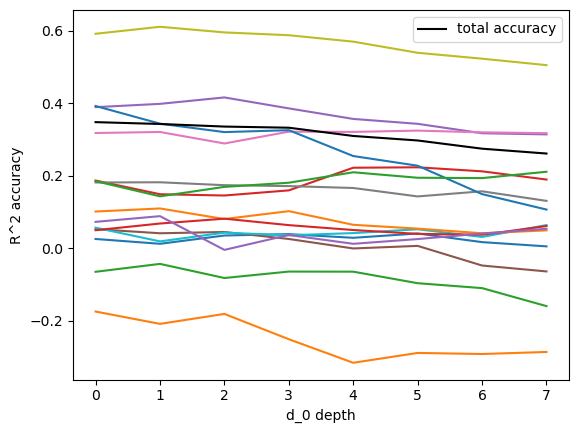

In [9]:
'''
Sourced Accuracy
'''

depth = np.arange(8)
for i in range(15):
    plt.plot(depth, sourced_accuracy_scores[:,i])
plt.plot(depth, accuracy_score, color = 'black', label = "total accuracy")
plt.xlabel('d_0 depth')
plt.ylabel('R^2 accuracy')
plt.legend()
#plt.ylim(0,1)

In [ ]:
'''
Histogram of First Split by label depth by trees
'''

flsd = [] #first label split depth
for i in range(10):
    flsd_temp = np.zeros(len(rf1[i].trees))
    for j in range(len(rf1[i].trees)):
        flsd_temp[j] = rf1[i].trees[j][0].first_label_split_depth
    flsd.append(flsd_temp)

plt.hist(flsd[0:4], stacked=False, bins = 16, label = ['Label Depth = 1', 'Label Depth = 2', 'Label Depth = 3', 'Label Depth = 4'])
plt.ylabel('Trees')
plt.xlabel('First label split')
plt.title('Distribution of First Label Split Depths')
plt.legend()

In [ ]:
rf = RandomForestRegressor(
    warm_start=True,      # allows incremental growing
    oob_score=True,
    bootstrap=True,
    min_samples_leaf = 5,
    max_features = 'sqrt'
)

oob_scores = []
n_trees_range = range(20, 1500)

for n in n_trees_range:
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    #print(n)

plt.plot(n_trees_range, oob_scores)
plt.xlabel("Number of Trees")
plt.ylabel("OOB R²")
plt.title("OOB Score vs Number of Trees")
plt.show()

In [ ]:
# Create an instance of RandomForestClassifier from scikit-learn
sklearn_rf = RandomForestRegressor(n_estimators=100, min_samples_leaf=10, max_features=0.4, max_depth = None, oob_score=False)

# Fit the scikit-learn model to the training data
sklearn_rf.fit(X_train, y_train)

# Make predictions using the scikit-learn model
sklearn_predictions = sklearn_rf.predict(X_test)

# Calculate the accuracy score for the scikit-learn predictions
sklearn_accuracy_score = sklearn_rf.score(X_test, y_test)
print(sklearn_accuracy_score)